In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [110]:
df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


Firstly you must always ask 5 questions from your data
1. data size you are dealing with
2. randomly watching the data

In [111]:
df.shape

(891, 15)

In [112]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
195,1,1,female,58.0,0,0,146.5208,C,First,woman,False,B,Cherbourg,yes,True
126,0,3,male,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
651,1,2,female,18.0,0,1,23.0000,S,Second,woman,False,NaN,Southampton,yes,False
248,1,1,male,37.0,1,1,52.5542,S,First,man,True,D,Southampton,yes,False
180,0,3,female,NaN,8,2,69.5500,S,Third,woman,False,NaN,Southampton,no,False


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Analysis of info column
- these 3 columns has missing values (age,deck,embark_town)

In [114]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Standard deviation batati hai ke data average se kitna door spread hua hua hai.

* Survived:  75%	1.000000 -> this shows ke mostly people were  died. 38.4 percent log survived and 61. 6 percent died
* pclass	2.308642	mostly people were in second and third class
* fare std is very large then mean mtlb data skewed hai wo bhi right min fare is 0 means ya to outlier hai ya to crew member ho sakta hai (normally fare ka spread 17.4 se 81.8 tk hai) The Fare column has an IQR of 23.09. The lower and upper bounds are −26.72 and 65.63, respectively. Since fares cannot be negative, there are no lower outliers. However, several passengers paid more than £65.63, with the maximum fare being £512.33. This indicates the presence of multiple upper outliers and suggests that the Fare distribution is positively (right) skewed. so 106 outliers hn.
* age min 0.43 hai means bache bhi the age age between 15 se 45 ke darmain hai is ka mtlb outliers bhi ho sakte hn so yh IQR use krn gae yes there are outliers in the uper bound 11 outliers


In [115]:
IQR=38-20.125
lower_bound=20.125-1.5*IQR
upper_bound=38+ 1.5*IQR
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


IQR: 17.875
Lower Bound: -6.6875
Upper Bound: 64.8125


In [116]:
Q1 = 7.9104
Q3 = 31.0000

IQR_fare = Q3 - Q1

lower_bound_fare = Q1 - 1.5 * IQR_fare
upper_bound_fare = Q3 + 1.5 * IQR_fare

print("IQR:", IQR_fare)
print("Lower Bound:", lower_bound_fare)
print("Upper Bound:", upper_bound_fare)

(df["fare"] > upper_bound_fare).sum()

IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344


np.int64(116)

For categorical columns, instead of outliers, we look at:
- Frequency counts
- Rare categories
- Class imbalance

In [117]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [118]:
survived_percent=(df["survived"].value_counts()[1])/len(df["survived"])*100
not_survived_percent=(df["survived"].value_counts()[0])/len(df["survived"])*100

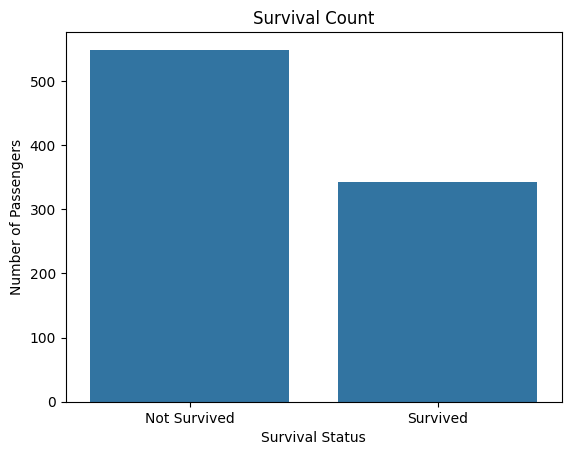

In [119]:
# i am checking here ke kitne logon ne survive kia aur kitne logon ne nhi to 
# 2 ways since this is a numerical col i can plot histogram to see th frequency count data is not continuous I can plot 
# bar chart 
# count pot bhi 
sns.countplot(x=df["survived"])
plt.title("survival distribution")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.title("Survival Count")
plt.show()

## Interpretation:
From survived column we could say that survived percentage is: "38.3" and not survived percentage is: "61.6"

In [120]:
df["pclass"].value_counts()
class_1=(df["pclass"].value_counts()[1])/len(df["pclass"])*100
class_2=(df["pclass"].value_counts()[2])/len(df["pclass"])*100
class_3=(df["pclass"].value_counts()[3])/len(df["pclass"])*100
class_1, class_2, class_3

(np.float64(24.242424242424242),
 np.float64(20.65095398428732),
 np.float64(55.106621773288445))

In [121]:
# since pclass is also a numerical co but it has not continuous values i can plot 
# bar chart
# histogram
# countplot

<Axes: xlabel='pclass', ylabel='count'>

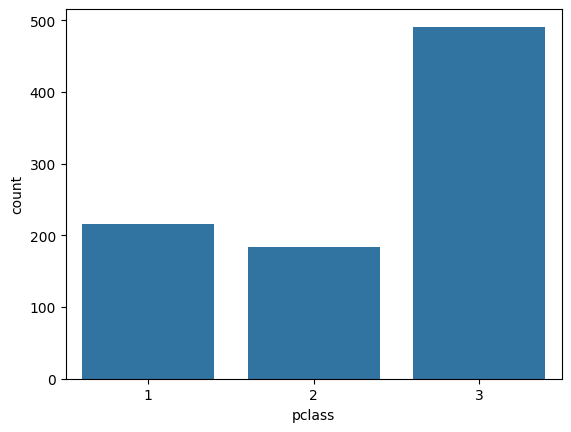

In [122]:
sns.countplot(x=df["pclass"])

## Interpretation:
Around 24.24 travelled in class 1, 20.65 travelled in class 2, 55.10 travelled in class 3 fare is positively corelated with price.

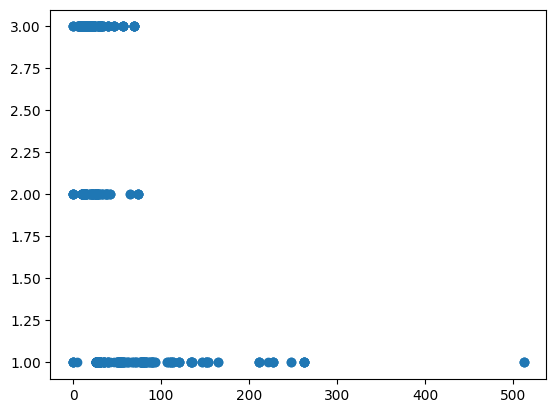

In [123]:
plt.scatter(x=df["fare"], y=df["pclass"])

In [124]:
df[df["pclass"]==1]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


<Axes: xlabel='fare', ylabel='Density'>

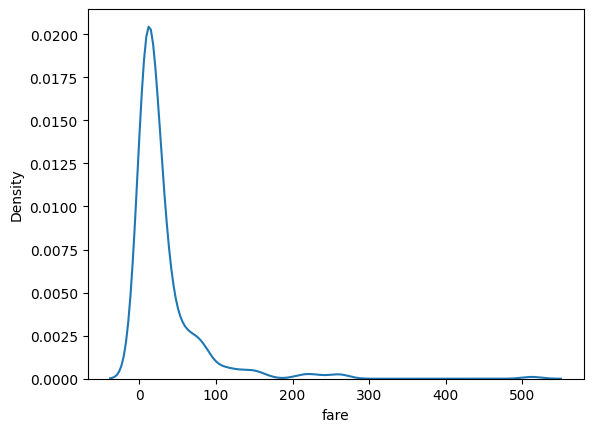

In [125]:
# IQR: 23.0896
# Lower Bound: -26.724
# Upper Bound: 65.6344
# Right-skewed distribution ➜ consider log1p() to reduce skewness and lessen the influence of large values.
sns.kdeplot(df["fare"]) # this graph is showing my data is right skewed so i am applying log1p

<Axes: xlabel='fare', ylabel='Density'>

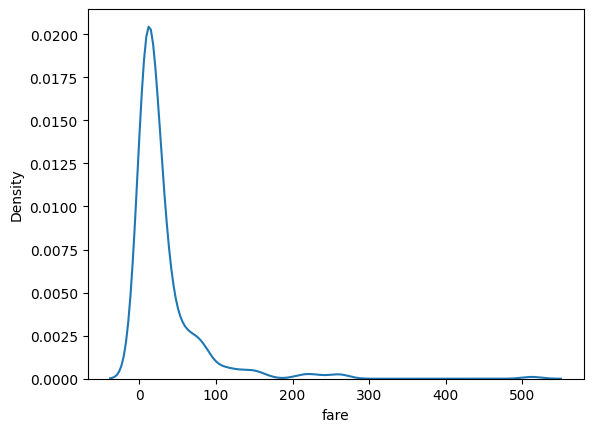

In [126]:
sns.kdeplot((df["fare"])) 

<Axes: xlabel='fare_log', ylabel='Density'>

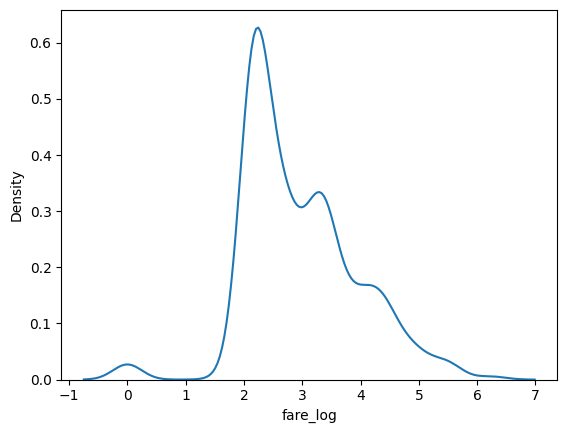

In [127]:
df["fare_log"] = np.log1p(df["fare"])

sns.kdeplot(df["fare_log"])

<Axes: xlabel='pclass', ylabel='fare'>

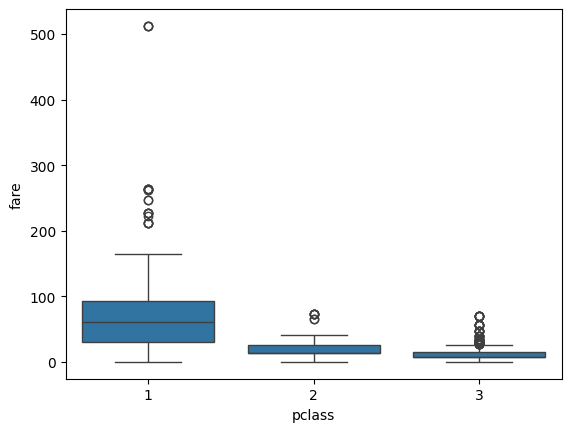

In [128]:
# fare for pclass 3(less), pclsss 2(med), pclass1(highest)
# fare and class can have some relation fare is numerical and class is categorical so i can make box plot
sns.boxplot(x="pclass", y="fare", data=df)

The boxplot shows that first-class passengers paid significantly higher fares than second- and third-class passengers. The fare distribution for first class is more spread out, indicating greater variability in ticket prices. Several high-fare outliers are present, especially in first class, including one extreme fare of approximately £512. Third-class passengers paid the lowest fares with relatively less variation. Overall, fare is strongly associated with passenger class.

In [129]:
df[df["pclass"]==1]["fare"].median()

np.float64(60.287499999999994)

In [130]:
df[df["pclass"]==2]["fare"].median()

np.float64(14.25)

In [131]:
df[df["pclass"]==3]["fare"].median()

np.float64(8.05)

### Hypothesis
"I want to investigate whether the typical fare of second class is close to either first or third class, which might help explain the distribution of passengers across classes."

In [132]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,fare_log
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2.110213
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,4.280593
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,2.188856
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,3.990834
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,2.202765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,2.639057
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,3.433987
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,3.196630
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,3.433987


<Axes: xlabel='sex', ylabel='count'>

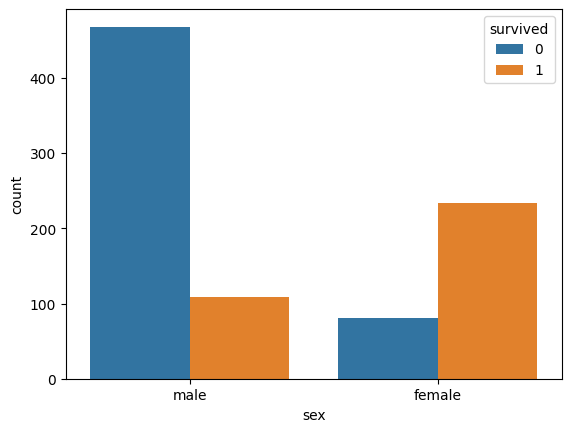

In [133]:
df.groupby("sex")["survived"].sum()
sns.countplot(x=df["sex"], hue=df["survived"])

## Interpretation: 
- Female has more survival rate then male

<Axes: xlabel='age', ylabel='Density'>

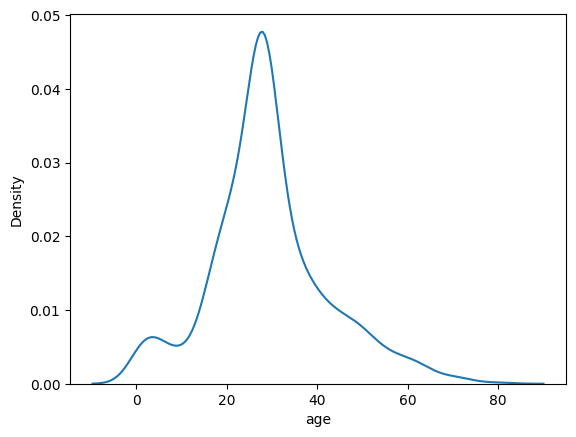

In [134]:
# IQR: 17.875
# Lower Bound: -6.6875
# Upper Bound: 64.8125
# age has outliers and the null values also so we have to take log1p and also fill the null values with median
# Age contains missing values, so we will impute them using the median
# because the median is more robust to outliers than the mean.
# Although Age has a few outliers, they are valid observations and
# do not require a log transformation.
df["age"] = df["age"].fillna(df["age"].median())
sns.kdeplot(x=df["age"])

<Axes: xlabel='survived', ylabel='age'>

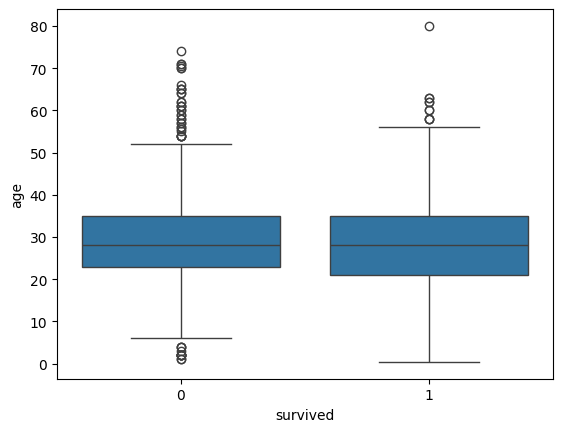

In [135]:
sns.boxplot(x=df["survived"], y=df["age"])

<Axes: xlabel='age', ylabel='Count'>

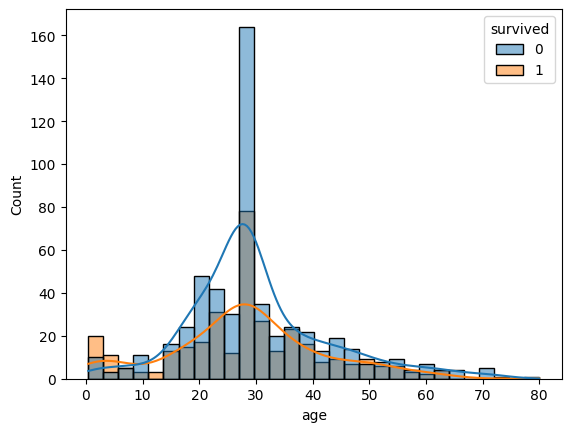

In [136]:
sns.histplot(data=df, x="age", hue="survived", bins=30, kde=True)

### Interpretation: 
- The histogram indicates that most Titanic passengers were between 20 and 35 years old. A relatively higher number of young children (0–10 years) survived compared to other age groups. In contrast, among adults aged 20–40 years, the number of non-survivors was greater than the number of survivors. However, since this plot shows counts rather than survival rates, further analysis using age-group survival percentages is needed before making firm conclusions about the effect of age on survival.

In [137]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

pd.crosstab(df["age_group"], df["survived"], normalize="index") * 100

survived,0,1
age_group,,
Child,42.028986,57.971014
Teen,57.142857,42.857143
Young Adult,64.672897,35.327103
Adult,60.000000,40.000000
Senior,77.272727,22.727273


In [138]:
pd.crosstab(df["age_group"], df["survived"])

survived,0,1
age_group,,
Child,29,40
Teen,40,30
Young Adult,346,189
Adult,117,78
Senior,17,5


### Interpretation: 
- Age appears to have a relationship with survival. Children had the highest survival rate (57.97%), while seniors had the lowest (22.73%). Young adults and adults also had lower survival rates than children. This suggests that younger passengers, particularly children, were more likely to survive than older passengers.

In [139]:
df["embarked"].isnull().sum() # 2 rows
df.dropna(subset=["embarked"], inplace=True)

### Interpretation:
- 'embarked' has only 2 missing values (0.22% of the dataset).
- Since the number of missing rows is very small,
- it is reasonable to remove them instead of imputing.

<Axes: xlabel='pclass', ylabel='count'>

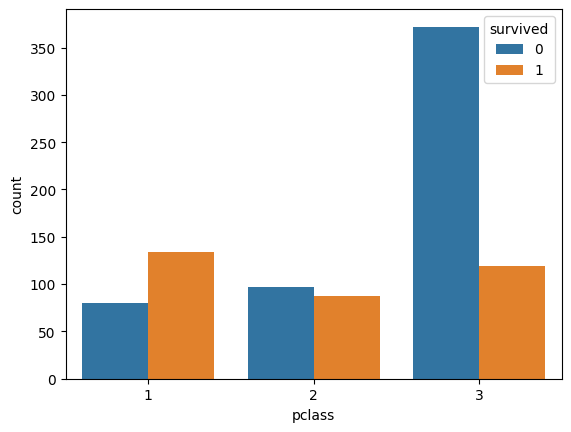

In [140]:
sns.countplot(x="pclass", hue="survived", data=df)

First-class passengers had the highest survival rate, while third-class passengers had the lowest.

<Axes: xlabel='embarked', ylabel='count'>

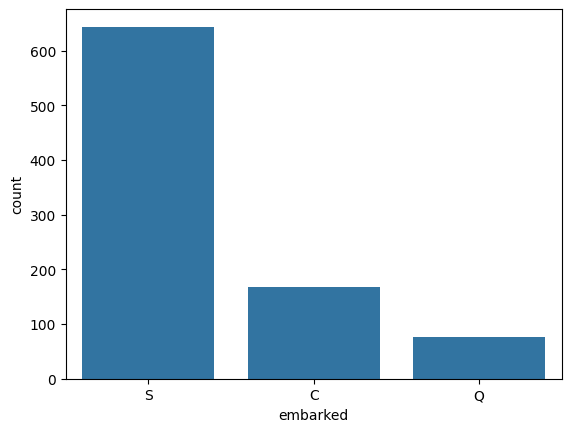

In [141]:
sns.countplot(x="embarked", data=df)

Most passengers boarded from Southampton (S).

<Axes: xlabel='sibsp', ylabel='Count'>

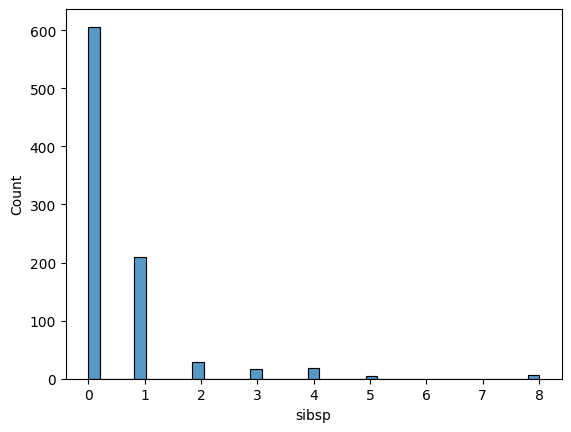

In [142]:
sns.histplot(df["sibsp"])

<Axes: xlabel='survived', ylabel='sibsp'>

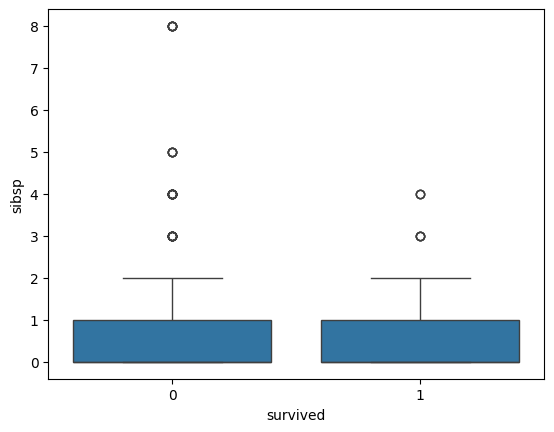

In [143]:
sns.boxplot(x="survived", y="sibsp", data=df)

<Axes: xlabel='sibsp', ylabel='survived'>

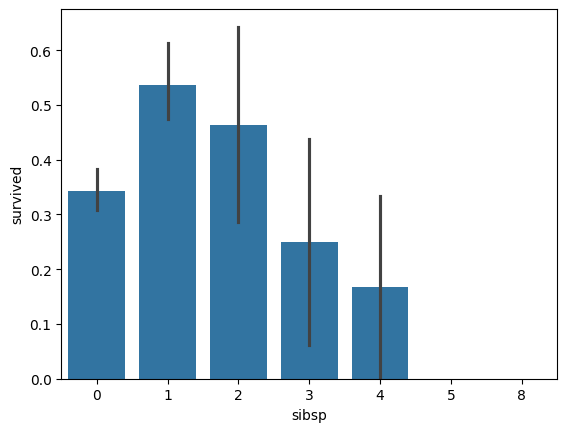

In [144]:
sns.barplot(x="sibsp", y="survived", data=df)

In [145]:
df.groupby("sibsp")["survived"].agg(["count", "mean"])

,count,mean
sibsp,,
0,606,0.343234
1,209,0.535885
2,28,0.464286
3,16,0.250000
4,18,0.166667
5,5,0.000000
8,7,0.000000


Passengers traveling with one sibling or spouse had the highest survival rate, while passengers traveling alone had a lower survival rate. As the number of siblings/spouses increased beyond two, the survival rate generally declined. This suggests that traveling with a small family may have improved the chances of survival, whereas traveling with a large family may have made evacuation more difficult

<Axes: >

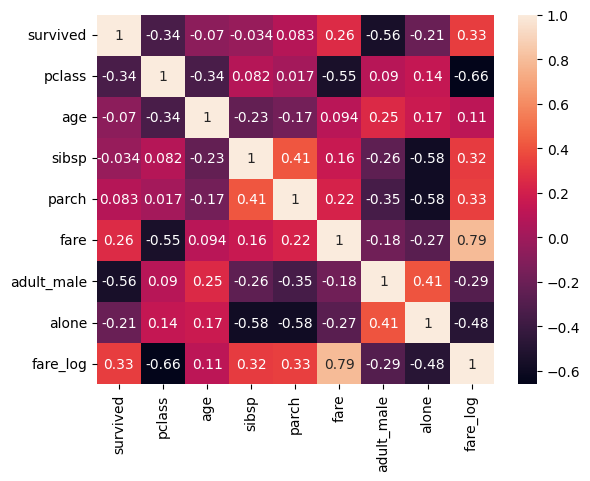

In [146]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

So, if someone asks you how to analyze a correlation heatmap, follow this order:

Start with the target variable (survived) and identify which features have the strongest positive and negative correlations.
Interpret the sign:
Positive → as one variable increases, the other tends to increase.
Negative → as one variable increases, the other tends to decrease.
Look for strong correlations between features (e.g., fare and fare_log). These can indicate multicollinearity, which is important for models like linear and logistic regression because highly correlated predictors can make coefficient estimates unstable.
Relate the correlations back to your earlier EDA (boxplots, histograms, countplots) to see if the findings are consistent.

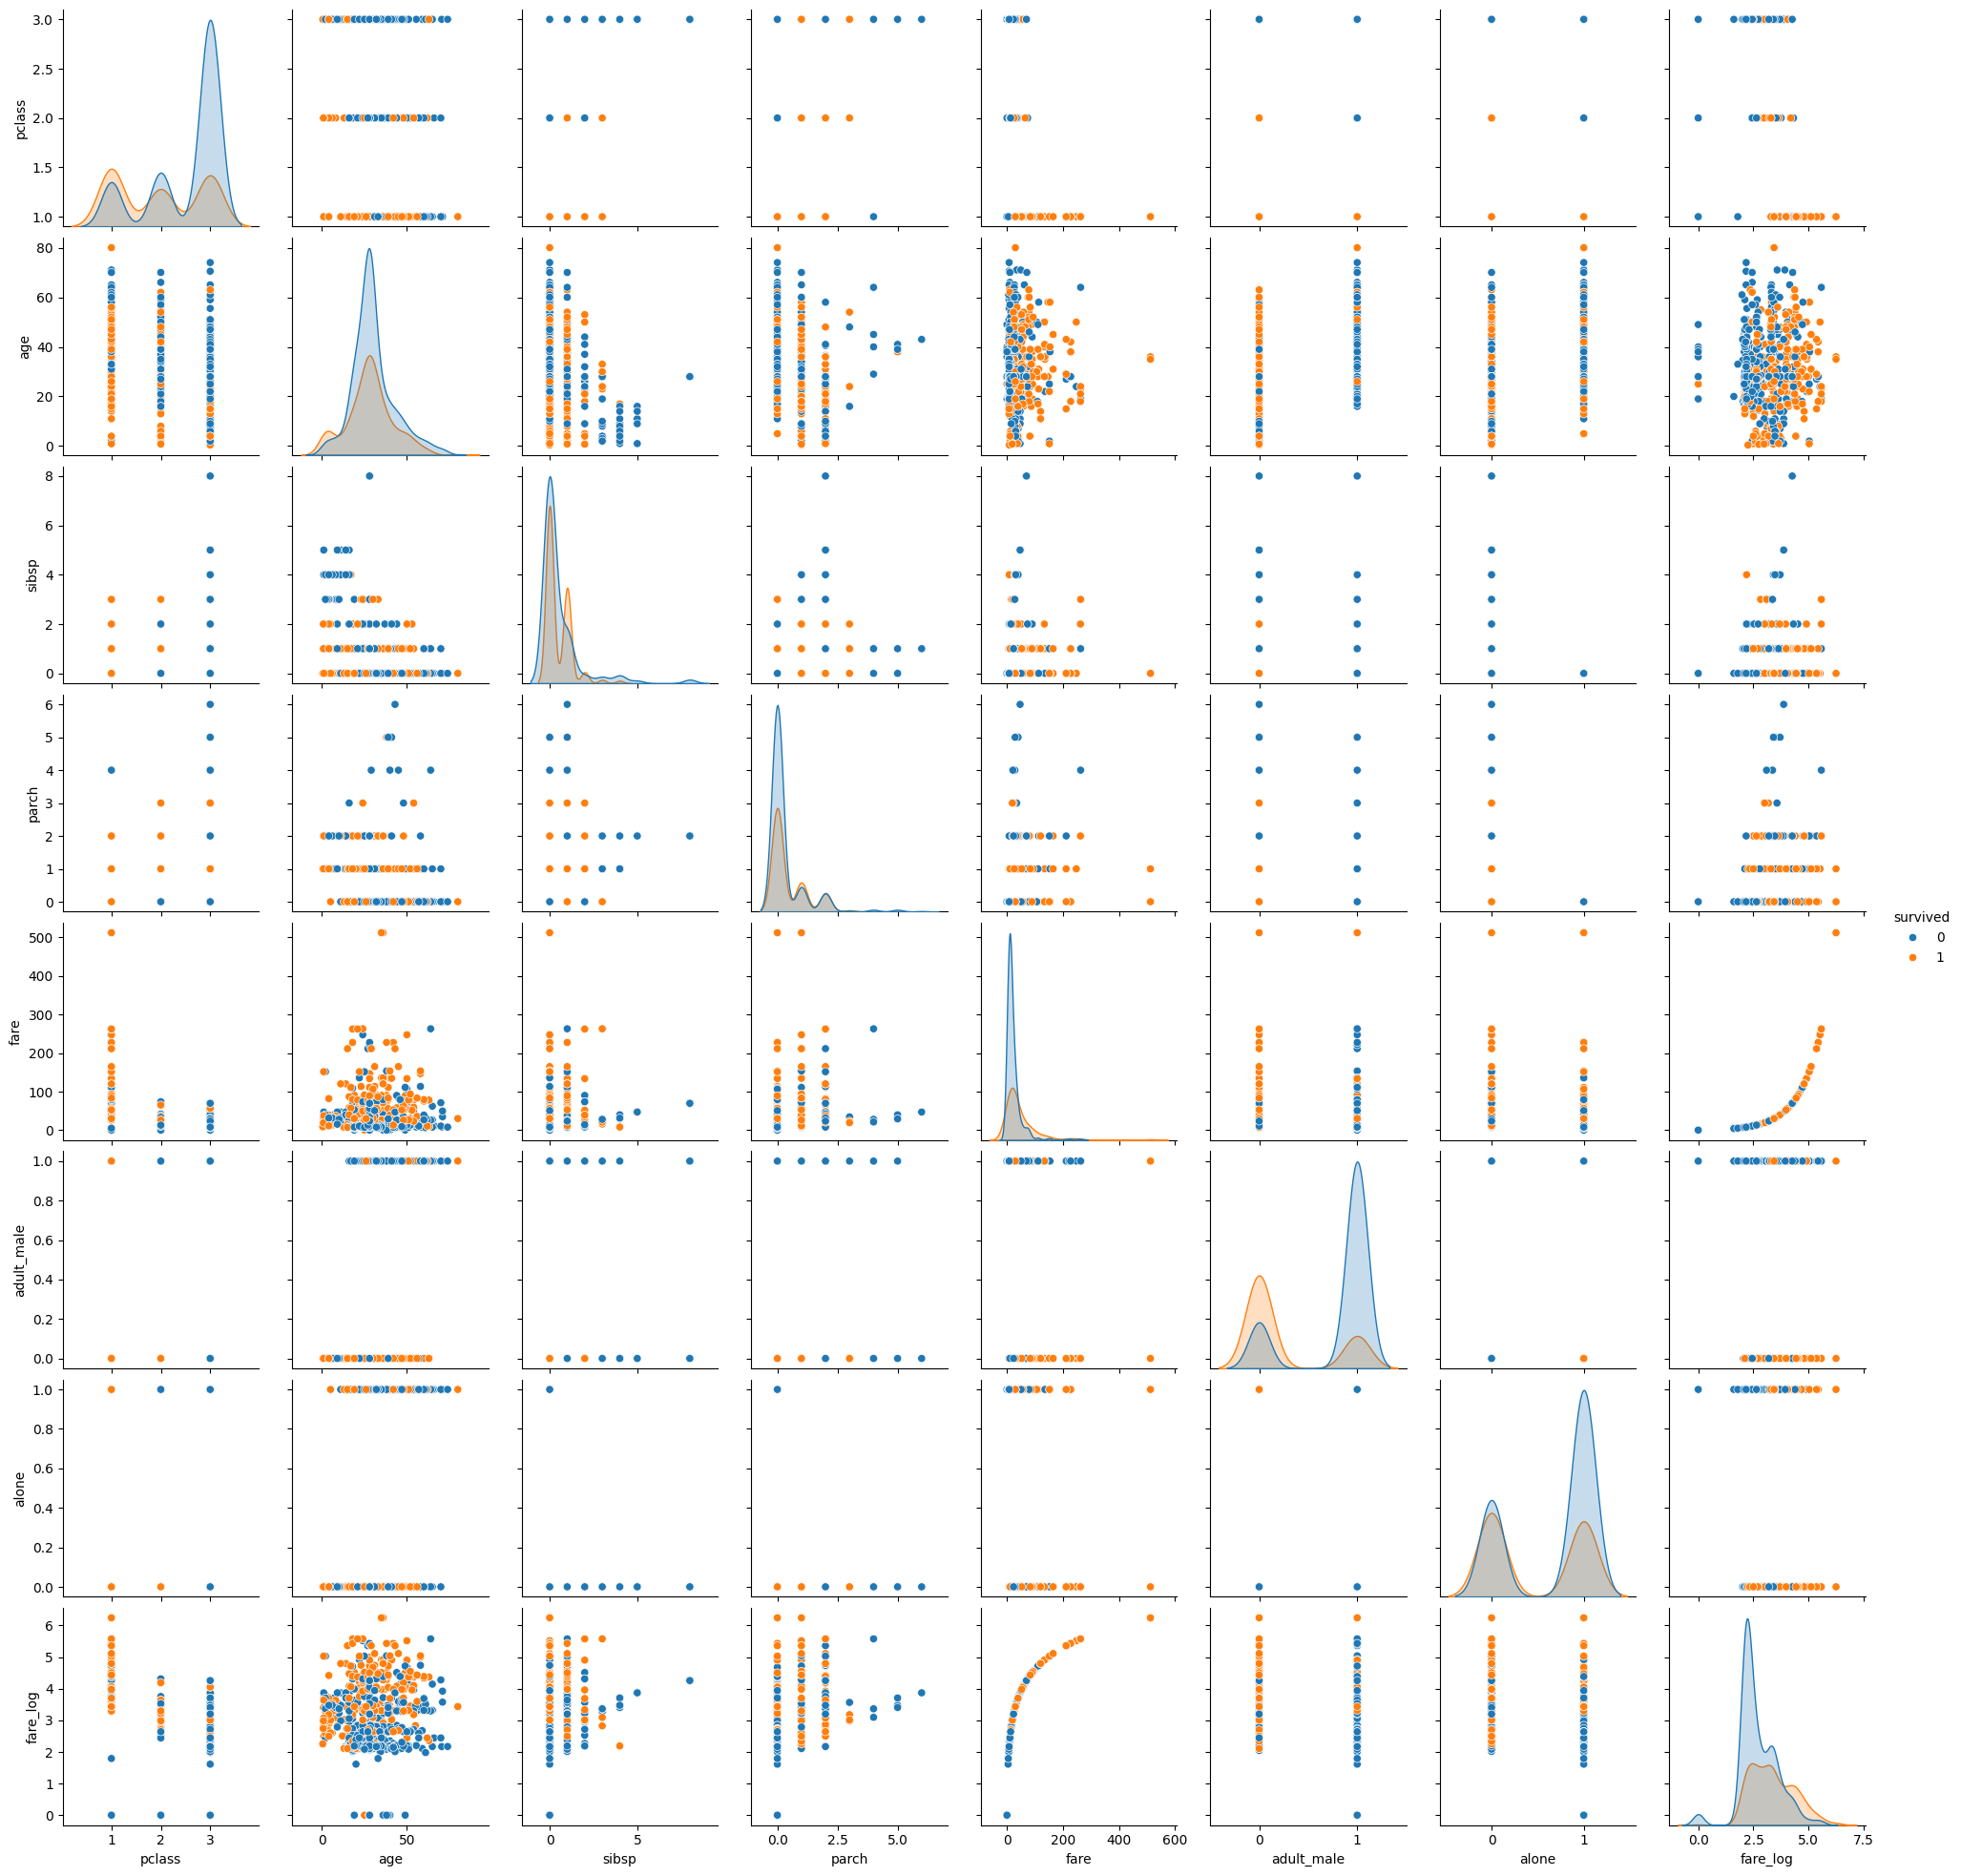

In [147]:
sns.pairplot(df, hue="survived")

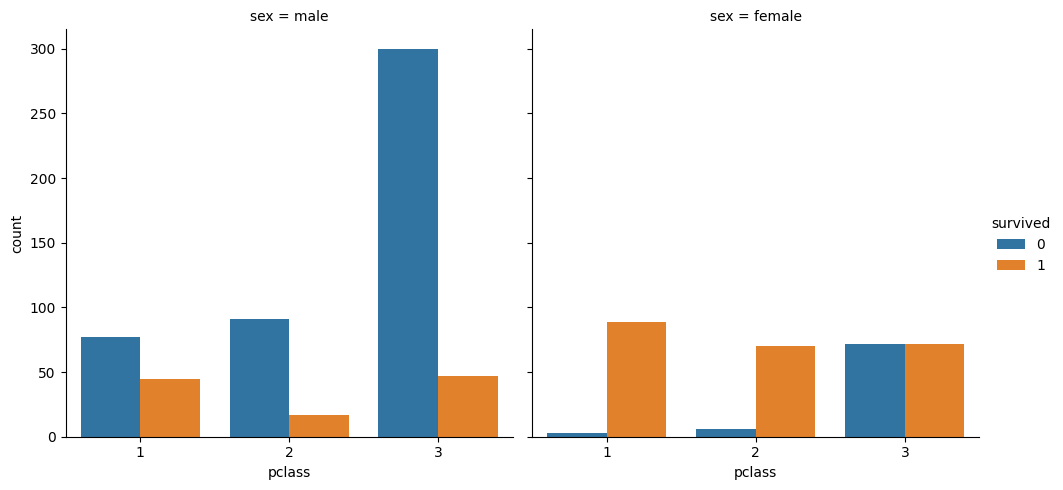

In [148]:
sns.catplot(
    x="pclass",
    hue="survived",
    col="sex",
    kind="count",
    data=df
)

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        889 non-null    category
 9   who          889 non-null    object  
 10  adult_male   889 non-null    bool    
 11  deck         201 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        889 non-null    object  
 14  alone        889 non-null    bool    
 15  fare_log     889 non-null    float64 
 16  age_group    889 non-null    category
dtypes: bool(2), category(3), float64(3), int64(4), object(5)
memory usage: 95.3+ K

In [167]:
df.drop(columns=["alive"], inplace=True)
df.drop(columns=["class"], inplace=True)
df.drop(columns=["deck"], inplace=True)
df.drop(columns=["embark_town"], inplace=True)
df.drop(columns=["who"], inplace=True)
df.drop(columns=["age_group"], inplace=True)

In [151]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'fare_log', 'age_group'],
      dtype='object')

In [152]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df[["embarked"]])

In [153]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["embarked"]),
    index=df.index
)

In [154]:
df = pd.concat([df.drop("embarked", axis=1), encoded_df], axis=1)

In [155]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,deck,embark_town,alive,alone,fare_log,age_group,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,Third,man,True,NaN,Southampton,no,False,2.110213,Young Adult,0.0,1.0
1,1,1,female,38.0,1,0,71.2833,First,woman,False,C,Cherbourg,yes,False,4.280593,Adult,0.0,0.0
2,1,3,female,26.0,0,0,7.9250,Third,woman,False,NaN,Southampton,yes,True,2.188856,Young Adult,0.0,1.0
3,1,1,female,35.0,1,0,53.1000,First,woman,False,C,Southampton,yes,False,3.990834,Young Adult,0.0,1.0
4,0,3,male,35.0,0,0,8.0500,Third,man,True,NaN,Southampton,no,True,2.202765,Young Adult,0.0,1.0


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   class        889 non-null    category
 8   who          889 non-null    object  
 9   adult_male   889 non-null    bool    
 10  deck         201 non-null    category
 11  embark_town  889 non-null    object  
 12  alive        889 non-null    object  
 13  alone        889 non-null    bool    
 14  fare_log     889 non-null    float64 
 15  age_group    889 non-null    category
 16  embarked_Q   889 non-null    float64 
 17  embarked_S   889 non-null    float64 
dtypes: bool(2), category(3), float64(5)

In [160]:
from sklearn.preprocessing import OneHotEncoder
encoder_sex = OneHotEncoder(drop="first", sparse_output=False)
encoded_sex = encoder_sex.fit_transform(df[["sex"]])

In [163]:
encoded_df_sex = pd.DataFrame(
    encoded_sex,
    columns=encoder_sex.get_feature_names_out(["sex"]),
    index=df.index
)

In [164]:
df = pd.concat([df.drop("sex", axis=1), encoded_df_sex], axis=1)

In [168]:
df

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,fare_log,embarked_Q,embarked_S,sex_male
0,0,3,22.0,1,0,7.2500,True,False,2.110213,0.0,1.0,1.0
1,1,1,38.0,1,0,71.2833,False,False,4.280593,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,False,True,2.188856,0.0,1.0,0.0
3,1,1,35.0,1,0,53.1000,False,False,3.990834,0.0,1.0,0.0
4,0,3,35.0,0,0,8.0500,True,True,2.202765,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,True,2.639057,0.0,1.0,1.0
887,1,1,19.0,0,0,30.0000,False,True,3.433987,0.0,1.0,0.0
888,0,3,28.0,1,2,23.4500,False,False,3.196630,0.0,1.0,0.0
889,1,1,26.0,0,0,30.0000,True,True,3.433987,0.0,0.0,1.0


In [169]:
df.drop(columns=["fare"], inplace=True)

In [170]:
df["adult_male"] = df["adult_male"].astype(int)
df["alone"] = df["alone"].astype(int)

In [171]:
df.to_csv("titanic_clean.csv", index=False)